In [1]:
import pandas as pd
import numpy as np

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve
)

DATA_PATH = Path("/ml_user_features_cutoff.csv")

df = pd.read_csv(DATA_PATH)

print(df.shape)
df.head()

(127868, 40)


,user_pseudo_id,label_future_purchase,first_session_date,last_session_date,days_since_last_session,observed_lifespan_days,first_device_category,first_traffic_source,first_traffic_medium,first_traffic_campaign,...,item_views_per_session,add_to_carts_per_session,checkouts_per_session,events_per_session,pct_sessions_with_product_view,pct_sessions_with_add_to_cart,pct_sessions_with_checkout,user_view_to_cart_session_rate,user_cart_to_checkout_session_rate,user_cart_abandonment_rate
0,7.258175e+07,0,2020-11-01,2020-11-01,44,0,desktop,<Other>,<Other>,<Other>,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,NaN,NaN,NaN
1,5.346296e+06,0,2020-11-01,2020-11-01,44,0,desktop,google,organic,(organic),...,0.0,0.0,0.0,2.0,0.0,0.0,0.0,NaN,NaN,NaN
2,7.386179e+06,0,2020-11-01,2020-11-01,44,0,mobile,(data deleted),(data deleted),(data deleted),...,0.0,0.0,0.0,2.0,0.0,0.0,0.0,NaN,NaN,NaN
3,1.206095e+07,0,2020-11-01,2020-11-01,44,0,mobile,(data deleted),(data deleted),(data deleted),...,0.0,0.0,0.0,2.0,0.0,0.0,0.0,NaN,NaN,NaN
4,2.002793e+06,0,2020-11-01,2020-11-01,44,0,desktop,shop.googlemerchandisestore.com,referral,(referral),...,0.0,0.0,0.0,2.0,0.0,0.0,0.0,NaN,NaN,NaN


In [2]:
df.info()

target = "label_future_purchase"

print(df[target].value_counts())
print(df[target].value_counts(normalize=True).round(4))

missing = (
    df.isna()
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
missing.columns = ["column", "missing_rate"]
missing.head(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 127868 entries, 0 to 127867
Data columns (total 40 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   user_pseudo_id                       127868 non-null  float64
 1   label_future_purchase                127868 non-null  int64  
 2   first_session_date                   127868 non-null  object 
 3   last_session_date                    127868 non-null  object 
 4   days_since_last_session              127868 non-null  int64  
 5   observed_lifespan_days               127868 non-null  int64  
 6   first_device_category                127868 non-null  object 
 7   first_traffic_source                 127868 non-null  object 
 8   first_traffic_medium                 127868 non-null  object 
 9   first_traffic_campaign               127868 non-null  object 
 10  first_country                        127868 non-null  object 
 11  favorite_view

,column,missing_rate
0,user_cart_abandonment_rate,0.960772
1,user_cart_to_checkout_session_rate,0.960772
2,user_view_to_cart_session_rate,0.758923
3,favorite_view_category,0.004966
4,favorite_cart_category,0.001001
5,user_pseudo_id,0.000000
6,first_session_date,0.000000
7,label_future_purchase,0.000000
8,first_traffic_source,0.000000
9,first_device_category,0.000000


In [3]:
# Structural missingness indicators
high_missing_cols = [
    "user_view_to_cart_session_rate",
    "user_cart_to_checkout_session_rate",
    "user_cart_abandonment_rate",
    "favorite_view_category",
    "favorite_cart_category",
]

for col in high_missing_cols:
    if col in df.columns:
        df[f"{col}_missing_flag"] = df[col].isna().astype(int)

target = "label_future_purchase"

leakage_cols = [
    "user_pseudo_id",
    "label_future_purchase",
    "first_session_date",
    "last_session_date",
]

date_cols = [
    "first_session_date",
    "last_session_date",
]

drop_cols = [c for c in leakage_cols + date_cols if c in df.columns]

X = df.drop(columns=drop_cols)
y = df[target]

numeric_features = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Feature matrix shape:", X.shape)
print("Positive rate:", y.mean().round(4))
print("Dropped columns:")
print(drop_cols)

# Sanity check for remaining suspicious columns
suspicious_terms = ["purchase", "revenue", "buyer", "transaction", "target", "label"]
remaining_suspicious = [
    c for c in X.columns
    if any(term in c.lower() for term in suspicious_terms)
]

print("\nRemaining suspicious columns:")
remaining_suspicious

Feature matrix shape: (127868, 41)
Positive rate: 0.0025
Dropped columns:
['user_pseudo_id', 'label_future_purchase', 'first_session_date', 'last_session_date', 'first_session_date', 'last_session_date']

Remaining suspicious columns:


[]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

label_future_purchase
0    0.997449
1    0.002551
Name: proportion, dtype: float64
label_future_purchase
0    0.997458
1    0.002542
Name: proportion, dtype: float64


In [5]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=50))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [6]:
log_reg_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

log_reg_model.fit(X_train, y_train)

y_pred = log_reg_model.predict(X_test)
y_proba = log_reg_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("PR-AUC:", average_precision_score(y_test, y_proba))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.88      0.94     25509
           1       0.01      0.68      0.03        65

    accuracy                           0.88     25574
   macro avg       0.51      0.78      0.48     25574
weighted avg       1.00      0.88      0.93     25574

ROC-AUC: 0.8469381847130877
PR-AUC: 0.031565560064309654
[[22425  3084]
 [   21    44]]


In [7]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=25,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_proba))
print("PR-AUC:", average_precision_score(y_test, rf_proba))
print(confusion_matrix(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98     25509
           1       0.03      0.48      0.06        65

    accuracy                           0.96     25574
   macro avg       0.51      0.72      0.52     25574
weighted avg       1.00      0.96      0.98     25574

ROC-AUC: 0.846821785372885
PR-AUC: 0.039994294364419085
[[24533   976]
 [   34    31]]


In [8]:
baseline_pr_auc = y_test.mean()

print("Baseline PR-AUC / Positive Rate:", baseline_pr_auc)
print("Logistic Regression PR-AUC Lift:", average_precision_score(y_test, y_proba) / baseline_pr_auc)
print("Random Forest PR-AUC Lift:", average_precision_score(y_test, rf_proba) / baseline_pr_auc)

Baseline PR-AUC / Positive Rate: 0.0025416438570423088
Logistic Regression PR-AUC Lift: 12.419348201302386
Random Forest PR-AUC Lift: 15.735601293471595


In [9]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.05, 0.95, 0.05)

threshold_results = []

for threshold in thresholds:
    preds = (rf_proba >= threshold).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall": recall_score(y_test, preds, zero_division=0),
        "f1": f1_score(y_test, preds, zero_division=0),
        "predicted_positive_rate": preds.mean()
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

,threshold,precision,recall,f1,predicted_positive_rate
0,0.05,0.003133,0.984615,0.006246,0.798741
1,0.10,0.004819,0.846154,0.009583,0.446313
2,0.15,0.006977,0.784615,0.013831,0.285837
3,0.20,0.009142,0.753846,0.018065,0.209588
4,0.25,0.011466,0.707692,0.022566,0.156878
5,0.30,0.014754,0.692308,0.028892,0.119262
6,0.35,0.019031,0.676923,0.037021,0.090404
7,0.40,0.021095,0.569231,0.040682,0.068585
8,0.45,0.024463,0.507692,0.046676,0.052749
9,0.50,0.030785,0.476923,0.057836,0.039376


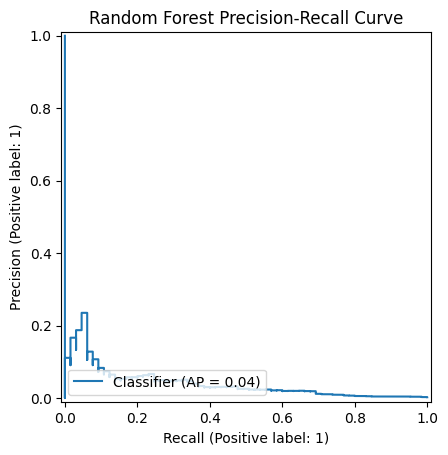

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(y_test, rf_proba)
plt.title("Random Forest Precision-Recall Curve")
plt.show()

In [11]:
eval_df = pd.DataFrame({
    "actual": y_test.values,
    "score": rf_proba
})

eval_df["score_decile"] = pd.qcut(
    eval_df["score"],
    q=10,
    labels=False,
    duplicates="drop"
) + 1

lift_table = (
    eval_df
    .groupby("score_decile")
    .agg(
        users=("actual", "count"),
        buyers=("actual", "sum"),
        purchase_rate=("actual", "mean"),
        avg_score=("score", "mean")
    )
    .reset_index()
    .sort_values("score_decile", ascending=False)
)

lift_table["baseline_purchase_rate"] = eval_df["actual"].mean()
lift_table["lift_vs_baseline"] = lift_table["purchase_rate"] / lift_table["baseline_purchase_rate"]

lift_table

,score_decile,users,buyers,purchase_rate,avg_score,baseline_purchase_rate,lift_vs_baseline
9,10,2558,45,0.017592,0.487764,0.002542,6.921453
8,9,2557,3,0.001173,0.262182,0.002542,0.461611
7,8,2557,4,0.001564,0.172225,0.002542,0.615481
6,7,2558,2,0.000782,0.124481,0.002542,0.307620
5,6,2556,2,0.000782,0.099414,0.002542,0.307861
4,5,2558,6,0.002346,0.082407,0.002542,0.922860
3,4,2551,2,0.000784,0.068973,0.002542,0.308464
2,3,2563,0,0.000000,0.056389,0.002542,0.000000
1,2,2558,1,0.000391,0.043512,0.002542,0.153810
0,1,2558,0,0.000000,0.027724,0.002542,0.000000


In [12]:
eval_df = pd.DataFrame({
    "actual": y_test.values,
    "score": rf_proba
}).sort_values("score", ascending=False).reset_index(drop=True)

baseline_rate = eval_df["actual"].mean()

cutoffs = [0.01, 0.02, 0.05, 0.10, 0.20]

top_lift_rows = []

for cutoff in cutoffs:
    n = int(len(eval_df) * cutoff)
    subset = eval_df.iloc[:n]

    top_lift_rows.append({
        "top_percent": f"Top {int(cutoff * 100)}%",
        "users": len(subset),
        "buyers": int(subset["actual"].sum()),
        "purchase_rate": subset["actual"].mean(),
        "baseline_purchase_rate": baseline_rate,
        "lift_vs_baseline": subset["actual"].mean() / baseline_rate
    })

top_lift_table = pd.DataFrame(top_lift_rows)
top_lift_table

,top_percent,users,buyers,purchase_rate,baseline_purchase_rate,lift_vs_baseline
0,Top 1%,255,16,0.062745,0.002542,24.686817
1,Top 2%,511,23,0.045010,0.002542,17.708927
2,Top 5%,1278,32,0.025039,0.002542,9.851547
3,Top 10%,2557,45,0.017599,0.002542,6.924160
4,Top 20%,5114,48,0.009386,0.002542,3.692885


In [13]:
from pathlib import Path

Path("../outputs").mkdir(exist_ok=True)

metrics = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "roc_auc": roc_auc_score(y_test, y_proba),
        "pr_auc": average_precision_score(y_test, y_proba),
        "baseline_pr_auc": baseline_pr_auc,
        "pr_auc_lift": average_precision_score(y_test, y_proba) / baseline_pr_auc
    },
    {
        "model": "Random Forest",
        "roc_auc": roc_auc_score(y_test, rf_proba),
        "pr_auc": average_precision_score(y_test, rf_proba),
        "baseline_pr_auc": baseline_pr_auc,
        "pr_auc_lift": average_precision_score(y_test, rf_proba) / baseline_pr_auc
    }
])


In [14]:
rf_preprocessor = rf_model.named_steps["preprocessor"]
rf_classifier = rf_model.named_steps["model"]

feature_names = rf_preprocessor.get_feature_names_out()
importances = rf_classifier.feature_importances_

feature_importance = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

feature_importance.head(25)

,feature,importance
0,num__total_events,0.105939
1,num__days_since_last_session,0.076048
2,num__total_page_views,0.063943
3,num__page_views_per_session,0.058688
4,num__item_views_per_session,0.053897
5,num__distinct_item_categories_interacted,0.053434
6,num__events_per_session,0.052426
7,num__total_item_views,0.051223
8,num__pct_sessions_with_product_view,0.042733
9,cat__favorite_view_category_(not set),0.037833


In [15]:
def clean_feature_name(feature):
    feature = feature.replace("num__", "").replace("cat__", "")
    feature = feature.replace("_", " ")
    return feature

feature_importance_clean = feature_importance.copy()
feature_importance_clean["clean_feature"] = feature_importance_clean["feature"].apply(clean_feature_name)

feature_importance_clean = feature_importance_clean[
    ["clean_feature", "feature", "importance"]
]

feature_importance_clean.head(25)

,clean_feature,feature,importance
0,total events,num__total_events,0.105939
1,days since last session,num__days_since_last_session,0.076048
2,total page views,num__total_page_views,0.063943
3,page views per session,num__page_views_per_session,0.058688
4,item views per session,num__item_views_per_session,0.053897
5,distinct item categories interacted,num__distinct_item_categories_interacted,0.053434
6,events per session,num__events_per_session,0.052426
7,total item views,num__total_item_views,0.051223
8,pct sessions with product view,num__pct_sessions_with_product_view,0.042733
9,favorite view category (not set),cat__favorite_view_category_(not set),0.037833


In [16]:
best_model = rf_model

df_scored = df.copy()

X_all = df.drop(columns=drop_cols)
df_scored["purchase_propensity_score"] = best_model.predict_proba(X_all)[:, 1]

df_scored["propensity_decile"] = pd.qcut(
    df_scored["purchase_propensity_score"],
    q=10,
    labels=False,
    duplicates="drop"
) + 1

df_scored["propensity_band"] = pd.cut(
    df_scored["purchase_propensity_score"],
    bins=[-0.01, 0.05, 0.15, 0.35, 1.0],
    labels=["Low", "Medium", "High", "Very High"]
)

scored_output_cols = [
    "user_pseudo_id",
    "purchase_propensity_score",
    "propensity_decile",
    "propensity_band",
    "label_future_purchase",
    "first_device_category",
    "first_traffic_source",
    "first_traffic_medium",
    "first_country",
    "favorite_view_category",
    "total_sessions",
    "total_events",
    "total_page_views",
    "total_item_views",
    "total_add_to_carts",
    "days_since_last_session",
]

df_scored[scored_output_cols].to_csv(
    "../outputs/purchase_propensity_scored_users.csv",
    index=False
)

In [17]:
from pathlib import Path

Path("../outputs").mkdir(exist_ok=True)

metrics.to_csv("../outputs/model_metrics.csv", index=False)

threshold_df.to_csv(
    "../outputs/threshold_tuning.csv",
    index=False
)

lift_table.to_csv(
    "../outputs/propensity_decile_lift.csv",
    index=False
)

top_lift_table.to_csv(
    "../outputs/top_percentile_lift.csv",
    index=False
)

feature_importance_clean.to_csv(
    "../outputs/model_feature_importance.csv",
    index=False
)

df_scored[scored_output_cols].to_csv(
    "../outputs/purchase_propensity_scored_users.csv",
    index=False
)

# Purchase Propensity Modeling Summary

## Objective

The goal of this phase was to build a purchase propensity model that predicts whether a user is likely to make a future purchase based only on behavior observed before a cutoff date.

The target variable was `label_future_purchase`.

This reframes the task as a realistic forward-looking prediction problem rather than predicting whether a user has already purchased.

---

## Modeling Approach

A cutoff-based feature table was created in BigQuery.

- Features were built using pre-cutoff behavior only.
- Users who had already purchased before the cutoff were excluded.
- The label identified whether an eligible user purchased after the cutoff.
- Leakage-prone fields such as revenue, transactions, purchase dates, and existing buyer labels were excluded.

Two models were trained:

- Logistic Regression
- Random Forest Classifier

The Random Forest model was selected as the final model because it produced slightly stronger PR-AUC and better positive-class ranking performance.

---

## Class Imbalance

The future-purchase event was extremely rare.

The positive class rate was approximately 0.25%.

Because of this imbalance, raw accuracy was not treated as a meaningful success metric.

The model was evaluated using:

- ROC-AUC
- PR-AUC
- Precision
- Recall
- Threshold analysis
- Lift analysis

---

## Model Performance

| Model | ROC-AUC | PR-AUC | Interpretation |
|---|---:|---:|---|
| Logistic Regression | ~0.845 | ~0.033 | Strong baseline ranking model |
| Random Forest | ~0.846 | ~0.036 | Selected final model |

The baseline PR-AUC was approximately equal to the positive class rate.

The Random Forest PR-AUC was roughly 14x higher than baseline, showing that the model ranks likely buyers substantially better than random targeting.

---

## Threshold Analysis

Default classification thresholds are not ideal for this problem because the purchase event is very rare.

Lower thresholds improved recall but created many false positives.

Higher thresholds improved precision but missed many future buyers.

Because of this, the model is best used as a ranking and prioritization model, not as a strict yes/no classifier.

---

## Lift Analysis

Lift analysis showed that the highest-scoring users had materially higher future purchase rates than the overall population.

This makes the model useful for:

- Retargeting prioritization
- High-intent audience creation
- Email campaign targeting
- Cart and browse recovery
- CRM segmentation
- Marketing resource allocation

The most useful business output is not the predicted class label, but the purchase propensity score and percentile ranking.

---

## Feature Importance

The most important predictors were related to:

- Total engagement volume
- Page-view depth
- Session recency
- Item views per session
- Events per session
- Product-category diversity
- Product-view behavior
- Session frequency

Top feature families included:

- Total events
- Total page views
- Days since last session
- Item views per session
- Events per session
- Distinct item categories interacted
- Percentage of sessions with product views
- Total sessions

This suggests that users who browse more deeply, interact with more product categories, and engage more recently are more likely to purchase in the future.

---

## Business Interpretation

The model provides a practical way to identify users who are more likely to convert in a future period.

Although the absolute purchase rate is low, the model improves prioritization by separating higher-propensity users from the general visitor population.

Recommended business uses include:

- Prioritize high-score users for remarketing
- Personalize product recommendations for engaged browsers
- Target recently active users with promotional messaging
- Focus recovery campaigns on users with stronger product-view and cart signals
- Monitor top-decile users as a high-intent audience segment

---

## Limitations

The model has several limitations:

- Future purchases are extremely rare, making precision naturally low.
- The GA4 demo dataset is obfuscated and contains grouped or missing attribution values.
- The model is trained on a limited observation window.
- The model should be interpreted as a ranking system, not a deterministic conversion predictor.

---

## Conclusion

The final Random Forest model demonstrates meaningful purchase-propensity ranking power in a highly imbalanced ecommerce setting.

The strongest predictors are behavioral and engagement-based, which aligns with practical product analytics intuition.

This phase extends the project beyond descriptive dashboards by adding predictive modeling, feature engineering, model evaluation, and business-oriented propensity scoring.